In [1]:
from importlib import reload
import utils
reload(utils)
from utils import *
execute_smoke_tests()

drawdown smoke test passed
sharpe smoke test passed
sortino smoke test passed
limit detection smoke test: OK
All smoke tests passed.


In [2]:
import pandas as pd
from utils import load_or_fetch, detect_limit_hits

# Your 10-stock sample + 4 indices. Adjust if your code list differs.
stocks = {
    'sh.688256': '寒武纪',
    'sh.688433': '华曙高科',
    'sh.600522': '中天科技',
    'sh.601211': '国泰君安',
    'sz.300348': '长亮科技',
    'sz.000848': '承德露露',
    'sz.002020': '京新药业',
    'sh.601995': '中金公司',
    'sz.000876': '新希望',
    'sh.600761': '安徽合力',
}

start, end = '2023-04-01', '2026-04-01'

rows = []
for code, name in stocks.items():
    df = load_or_fetch(code, start, end)
    hits = detect_limit_hits(df, code)

    n_days = len(hits) - 1  # exclude first row (NaN return, forced non-limit)
    n_up = int(hits['limit_up'].sum())
    n_down = int(hits['limit_down'].sum())
    n_any = int(hits['any_limit'].sum())
    board = hits['board_limit'].iloc[0]

    rows.append({
        'Name': name,
        'Code': code,
        'Board_Limit': f'±{int(board*100)}%',
        'Trading_Days': n_days,
        'Limit_Up': n_up,
        'Limit_Down': n_down,
        'Total_Limits': n_any,
        'Limit_Pct': round(100 * n_any / n_days, 2),
    })

limit_table = pd.DataFrame(rows).sort_values('Limit_Pct', ascending=False)
print(limit_table.to_string(index=False))

Name      Code Board_Limit  Trading_Days  Limit_Up  Limit_Down  Total_Limits  Limit_Pct
 寒武纪 sh.688256        ±20%           724         9           1            10       1.38
安徽合力 sh.600761        ±10%           724         3           2             5       0.69
中金公司 sh.601995        ±10%           724         4           1             5       0.69
京新药业 sz.002020        ±10%           724         3           0             3       0.41
华曙高科 sh.688433        ±20%           715         1           1             2       0.28
中天科技 sh.600522        ±10%           724         1           1             2       0.28
国泰君安 sh.601211        ±10%           724         2           0             2       0.28
长亮科技 sz.300348        ±20%           724         2           0             2       0.28
承德露露 sz.000848        ±10%           724         1           0             1       0.14
 新希望 sz.000876        ±10%           724         1           0             1       0.14


In [3]:
# Primary candidate: ST长康.
# Window pads a month on each side to show pre-event normalcy and post-delisting tail.
st_changkang = load_or_fetch('sz.002435', '2024-04-01', '2024-08-15')
print(f'Rows returned: {len(st_changkang)}')
print(f'Date range: {st_changkang.index.min()} to {st_changkang.index.max()}')
print(st_changkang.head())
print(st_changkang.tail())

Rows returned: 93
Date range: 2024-04-01 00:00:00 to 2024-08-15 00:00:00
            open  high   low  close      volume       amount  pctChg
date                                                                
2024-04-01  3.14  3.39  3.13   3.25  23568689.0  76153915.54  3.5032
2024-04-02  3.21  3.24  3.17   3.19  15505668.0  49467077.56 -1.8462
2024-04-03  3.20  3.22  3.15   3.19  10857968.0  34580186.92  0.0000
2024-04-08  3.17  3.17  3.08   3.09  12361419.0  38612692.28 -3.1348
2024-04-09  3.07  3.13  3.07   3.13   8259135.0  25620536.80  1.2945
            open  high   low  close  volume  amount  pctChg
date                                                       
2024-08-09  0.37  0.37  0.37   0.37     NaN     NaN     NaN
2024-08-12  0.37  0.37  0.37   0.37     NaN     NaN     NaN
2024-08-13  0.37  0.37  0.37   0.37     NaN     NaN     NaN
2024-08-14  0.37  0.37  0.37   0.37     NaN     NaN     NaN
2024-08-15  0.37  0.37  0.37   0.37     NaN     NaN     NaN


In [4]:
from importlib import reload
import utils
reload(utils)
from utils import detect_limit_hits

import numpy as np
import pandas as pd

# Apply with ST override.
hits = detect_limit_hits(st_changkang, 'sz.002435', override_limit=0.05)

# Basic counts.
n_days_with_return = (~hits['daily_return'].isna()).sum()
n_up = int(hits['limit_up'].sum())
n_down = int(hits['limit_down'].sum())
print('ST长康, 2024-04-01 to 2024-08-15:')
print(f'  Trading days with returns: {n_days_with_return}')
print(f'  涨停 days (+5%): {n_up}')
print(f'  跌停 days (-5%): {n_down}')
print(f'  跌停 fraction of trading days: {100 * n_down / n_days_with_return:.1f}%')

# Identify consecutive 跌停 runs.
limit_down = hits['limit_down'].values
runs = []
start_i, length = None, 0
for i, is_down in enumerate(limit_down):
    if is_down:
        if start_i is None:
            start_i = i
        length += 1
    else:
        if length > 0:
            runs.append({
                'start': hits.index[start_i].date(),
                'end':   hits.index[i - 1].date(),
                'length': length,
            })
        start_i, length = None, 0
if length > 0:
    runs.append({
        'start': hits.index[start_i].date(),
        'end':   hits.index[-1].date(),
        'length': length,
    })

print(f'\nNumber of distinct 跌停 runs: {len(runs)}')
if runs:
    longest = max(runs, key=lambda r: r['length'])
    print(f'Longest run: {longest["length"]} consecutive 跌停 days, '
          f'{longest["start"]} → {longest["end"]}')
    print('All runs of length >= 3:')
    for r in runs:
        if r['length'] >= 3:
            print(f'  {r["start"]} → {r["end"]} ({r["length"]} days)')

# Peak-to-trough decline, excluding halted rows.
traded = st_changkang[st_changkang['volume'].notna() & (st_changkang['volume'] > 0)]
peak_price = traded['close'].max()
peak_date = traded['close'].idxmax().date()
trough_price = traded['close'].min()
trough_date = traded['close'].idxmin().date()
decline = trough_price / peak_price - 1

print(f'\nPeak (in traded rows): {peak_price:.2f} on {peak_date}')
print(f'Trough (last traded): {trough_price:.2f} on {trough_date}')
print(f'Cumulative decline peak to trough: {100 * decline:.1f}%')

# Volume collapse signature: compare average volume on 跌停 days vs normal days.
normal_days = hits[~hits['any_limit'] & st_changkang['volume'].notna() & (st_changkang['volume'] > 0)].index
limit_down_days = hits[hits['limit_down']].index
vol_normal = st_changkang.loc[normal_days, 'volume'].mean()
vol_limit_down = st_changkang.loc[limit_down_days, 'volume'].mean() if len(limit_down_days) > 0 else np.nan
print(f'\nAverage volume on normal days: {vol_normal:,.0f} shares')
print(f'Average volume on 跌停 days:    {vol_limit_down:,.0f} shares')
print(f'Volume ratio (跌停 / normal):   {vol_limit_down / vol_normal:.2f}')

ST长康, 2024-04-01 to 2024-08-15:
  Trading days with returns: 92
  涨停 days (+5%): 0
  跌停 days (-5%): 40
  跌停 fraction of trading days: 43.5%

Number of distinct 跌停 runs: 1
Longest run: 40 consecutive 跌停 days, 2024-05-06 → 2024-07-01
All runs of length >= 3:
  2024-05-06 → 2024-07-01 (40 days)

Peak (in traded rows): 3.25 on 2024-04-01
Trough (last traded): 0.37 on 2024-07-01
Cumulative decline peak to trough: -88.6%

Average volume on normal days: 12,703,243 shares
Average volume on 跌停 days:    793,250 shares
Volume ratio (跌停 / normal):   0.06


In [5]:
# Show all rows in the crisis period with return between -6% and -3%,
# along with whether our utility flagged them as 跌停.
crisis = st_changkang.loc['2024-05-06':'2024-07-05'].copy()
crisis['return'] = crisis['close'].pct_change()
crisis['flagged'] = hits.loc[crisis.index, 'limit_down']

suspicious = crisis[
    (crisis['return'] < -0.03)
    & (crisis['return'] > -0.06)
    & (crisis['volume'].notna())
].copy()
suspicious['return_pct'] = (suspicious['return'] * 100).round(2)

# Reconstruct what the actual 跌停价 would have been from prev_close,
# using the A-share away-from-zero rounding convention.
import numpy as np
def round_half_away(x, decimals=2):
    factor = 10 ** decimals
    return np.sign(x) * np.floor(np.abs(x) * factor + 0.5) / factor

prev_close = crisis['close'].shift(1)
reconstructed_limit_price = round_half_away(prev_close * 0.95, 2)
suspicious['reconstructed_跌停价'] = reconstructed_limit_price.loc[suspicious.index]
suspicious['at_跌停价'] = (
    suspicious['close'] == suspicious['reconstructed_跌停价']
)

cols = ['close', 'return_pct', 'flagged', 'reconstructed_跌停价', 'at_跌停价']
print(suspicious[cols].to_string())
print(f'\nRows with return in [-6%, -3%] that our utility flagged: '
      f'{suspicious["flagged"].sum()} / {len(suspicious)}')
print(f'Rows where close == reconstructed 跌停价: '
      f'{suspicious["at_跌停价"].sum()} / {len(suspicious)}')

            close  return_pct  flagged  reconstructed_跌停价  at_跌停价
date                                                             
2024-05-07   2.57       -4.81     True               2.57    True
2024-05-08   2.44       -5.06     True               2.44    True
2024-05-09   2.32       -4.92     True               2.32    True
2024-05-10   2.20       -5.17     True               2.20    True
2024-05-13   2.09       -5.00     True               2.09    True
2024-05-14   1.99       -4.78     True               1.99    True
2024-05-15   1.89       -5.03     True               1.89    True
2024-05-16   1.80       -4.76     True               1.80    True
2024-05-17   1.71       -5.00     True               1.71    True
2024-05-20   1.62       -5.26     True               1.62    True
2024-05-21   1.54       -4.94     True               1.54    True
2024-05-22   1.46       -5.19     True               1.46    True
2024-05-23   1.39       -4.79     True               1.39    True
2024-05-24

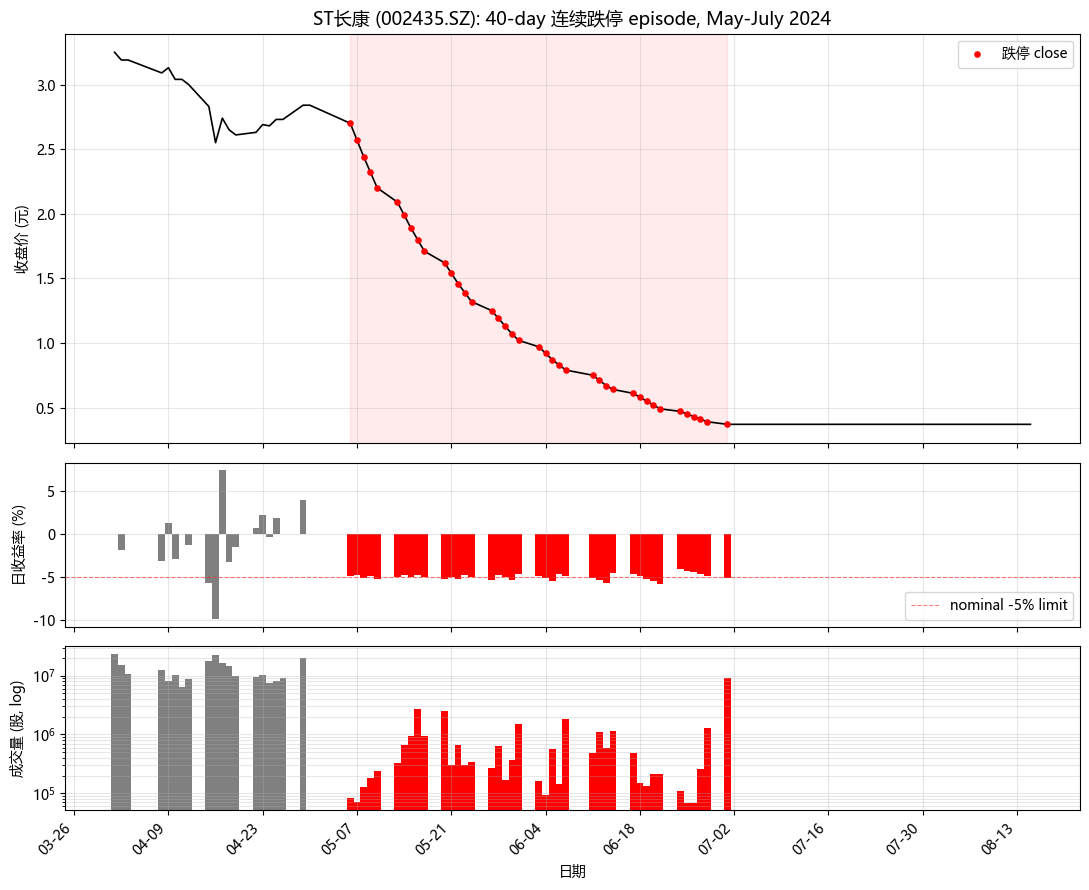

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from plot_setup import setup_chinese_font  # or whatever your setup call is
setup_chinese_font()

fig, (ax_price, ax_ret, ax_vol) = plt.subplots(
    3, 1, figsize=(11, 9), sharex=True,
    gridspec_kw={'height_ratios': [2.5, 1, 1]}
)

# Panel 1: price path with limit-down days highlighted.
ax_price.plot(st_changkang.index, st_changkang['close'], color='black', lw=1.2)
limit_down_idx = hits[hits['limit_down']].index
ax_price.scatter(
    limit_down_idx,
    st_changkang.loc[limit_down_idx, 'close'],
    color='red', s=14, zorder=5, label='跌停 close'
)
ax_price.axvspan(pd.Timestamp('2024-05-06'), pd.Timestamp('2024-07-01'),
                 alpha=0.08, color='red')
ax_price.set_ylabel('收盘价 (元)')
ax_price.set_title('ST长康 (002435.SZ): 40-day 连续跌停 episode, May-July 2024',
                   fontsize=13)
ax_price.legend(loc='upper right')
ax_price.grid(alpha=0.3)

# Panel 2: daily returns, with -5% reference line.
ax_ret.bar(st_changkang.index, hits['daily_return'] * 100,
           color=['red' if d else 'gray' for d in hits['limit_down']],
           width=1.0)
ax_ret.axhline(-5, color='red', linestyle='--', alpha=0.5, lw=0.8,
               label='nominal -5% limit')
ax_ret.set_ylabel('日收益率 (%)')
ax_ret.legend(loc='lower right')
ax_ret.grid(alpha=0.3)

# Panel 3: volume, log scale.
ax_vol.bar(st_changkang.index, st_changkang['volume'],
           color=['red' if d else 'gray' for d in hits['limit_down']],
           width=1.0)
ax_vol.set_yscale('log')
ax_vol.set_ylabel('成交量 (股, log)')
ax_vol.set_xlabel('日期')
ax_vol.grid(alpha=0.3, which='both')
ax_vol.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax_vol.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

plt.setp(ax_vol.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('data/ST_changkang_case.png', dpi=140, bbox_inches='tight')
plt.show()